# Import Essential Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
from warnings import filterwarnings
import seaborn as sns
filterwarnings("ignore")

# Import Data

In [2]:
df=pd.read_spss("BDHS_2017-2018.sav")
df.head()

,V013,V024,V025,V106,V701,V130,V151,V201,V123,V124,...,V190A,V113,V116,V161,V213,V404,V743A,V312,V501,BMI2
0,15-19,Rajshahi,Rural,Secondary,No education,Islam,Male,No child,No,No,...,Poorest,Improved,Improved,Solid fuel,No or unsure,No,Respondent and husband/partner,Modern methods,Married,Underweight/Normal
1,45-49,Rangpur,Urban,Primary,No education,Islam,Male,More than two child,No,No,...,Poorest,Improved,Improved,Solid fuel,No or unsure,No,Respondent and husband/partner,Traditional methods,Married,Underweight/Normal
2,15-19,Khulna,Rural,Secondary,Primary,Islam,Male,One child,No,No,...,Poorer,Improved,Improved,Solid fuel,No or unsure,Yes,Respondent and husband/partner,Modern methods,Married,Underweight/Normal
3,40-44,Barisal,Urban,Primary,Primary,Islam,Male,More than two child,No,No,...,Poorest,Improved,Improved,Solid fuel,No or unsure,No,Respondent and husband/partner,Not using,Married,Underweight/Normal
4,25-29,Barisal,Rural,Secondary,Higher,Islam,Male,One child,No,No,...,Richest,Improved,Improved,Solid fuel,Yes,No,Respondent and husband/partner,Not using,Married,Underweight/Normal


# Get some Basic Information

In [3]:
df.shape

(16303, 28)

In [4]:
df.columns

Index(['V013', 'V024', 'V025', 'V106', 'V701', 'V130', 'V151', 'V201', 'V123',
       'V124', 'V125', 'V119', 'V122', 'V121', 'V159', 'V716', 'V704', 'V190',
       'V190A', 'V113', 'V116', 'V161', 'V213', 'V404', 'V743A', 'V312',
       'V501', 'BMI2'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16303 entries, 0 to 16302
Data columns (total 28 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   V013    16303 non-null  category
 1   V024    16303 non-null  category
 2   V025    16303 non-null  category
 3   V106    16303 non-null  category
 4   V701    16303 non-null  category
 5   V130    16303 non-null  category
 6   V151    16303 non-null  category
 7   V201    16303 non-null  category
 8   V123    16303 non-null  category
 9   V124    16303 non-null  category
 10  V125    16303 non-null  category
 11  V119    16303 non-null  category
 12  V122    16303 non-null  category
 13  V121    16303 non-null  category
 14  V159    16303 non-null  category
 15  V716    16303 non-null  category
 16  V704    16303 non-null  category
 17  V190    16303 non-null  category
 18  V190A   16303 non-null  category
 19  V113    16303 non-null  category
 20  V116    16303 non-null  category
 21  V161    1630

In [6]:
df.isna().sum().sum(), df.isnull().sum().sum()

(0, 0)

In [7]:
df.BMI2.value_counts()

BMI2
Underweight/Normal    10951
Overweight/Obese       5352
Name: count, dtype: int64

In [8]:
BMI_2=df.BMI2.value_counts().index

In [9]:
BMI_2_Val=df.BMI2.value_counts().values

In [10]:
x=df[['V013', 'V024', 'V025', 'V106', 'V701', 'V130', 'V151', 'V201','V123','V124','V125','V119','V122','V121','V159','V716','V704', 'V190','V190A','V113','V116','V161','V213','V404','V743A','V312','V501']]

In [11]:
x

,V013,V024,V025,V106,V701,V130,V151,V201,V123,V124,...,V190,V190A,V113,V116,V161,V213,V404,V743A,V312,V501
0,15-19,Rajshahi,Rural,Secondary,No education,Islam,Male,No child,No,No,...,Poorest,Poorest,Improved,Improved,Solid fuel,No or unsure,No,Respondent and husband/partner,Modern methods,Married
1,45-49,Rangpur,Urban,Primary,No education,Islam,Male,More than two child,No,No,...,Poorest,Poorest,Improved,Improved,Solid fuel,No or unsure,No,Respondent and husband/partner,Traditional methods,Married
2,15-19,Khulna,Rural,Secondary,Primary,Islam,Male,One child,No,No,...,Poorer,Poorer,Improved,Improved,Solid fuel,No or unsure,Yes,Respondent and husband/partner,Modern methods,Married
3,40-44,Barisal,Urban,Primary,Primary,Islam,Male,More than two child,No,No,...,Poorest,Poorest,Improved,Improved,Solid fuel,No or unsure,No,Respondent and husband/partner,Not using,Married
4,25-29,Barisal,Rural,Secondary,Higher,Islam,Male,One child,No,No,...,Richer,Richest,Improved,Improved,Solid fuel,Yes,No,Respondent and husband/partner,Not using,Married
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16298,30-34,Dhaka,Urban,Higher,Higher,Islam,Male,More than two child,Yes,Yes,...,Richest,Richer,Improved,Unimproved,Clean fuel,No or unsure,No,Respondent and husband/partner,Modern methods,Married
16299,30-34,Rajshahi,Urban,No education,No education,Islam,Male,Two child,Yes,Yes,...,Richest,Richer,Improved,Unimproved,Clean fuel,No or unsure,No,Respondent and husband/partner,Modern methods,Married
16300,25-29,Dhaka,Urban,Higher,Higher,Islam,Male,More than two child,Yes,Yes,...,Richest,Richer,Improved,Unimproved,Clean fuel,No or unsure,No,Respondent and husband/partner,Modern methods,Married
16301,20-24,Dhaka,Urban,Secondary,Secondary,Islam,Male,Two child,No,No,...,Richest,Richest,Improved,Unimproved,Clean fuel,No or unsure,No,Respondent alone,Modern methods,Married


In [12]:
x['V013']=x['V013'].map({'15-19': 1, '20-24': 2, '25-29': 3 ,'30-34': 4, '35-39':5, '40-44':6, '45-49':7})
x['V024']=x['V024'].map({'Barisal': 1, 'Chittagong': 2,'Dhaka':3, 'Khulna':4, 'Mymensingh':5, 'Rajshahi':6, 'Rangpur':7, 'Sylhet':8})
x['V025']= x['V025'].map({'Urban':1, 'Rural': 2})
x['V106']= x['V106'].map({'No education':0, 'Primary': 1, 'Secondary':2, 'Higher':3})
x['V701']= x['V701'].map({'No education':0, 'Primary': 1, 'Secondary':2, 'Higher':3, "Don't know":4})
x['V130']= x['V130'].map({'Islam':0, 'Hinduism': 1, 'Buddhism':2, 'Christianity':3})
x['V151']= x['V151'].map({'Male':1, 'Female': 2})
x['V201']= x['V201'].map({'No child':0, 'One child': 1, 'Two child':2, 'More than two child':3})
x['V123']= x['V123'].map({'No':0, 'Yes': 1})
x['V124']= x['V124'].map({'No':0, 'Yes': 1})
x['V125']= x['V125'].map({'No':0, 'Yes': 1})
x['V119']= x['V119'].map({'No':0, 'Yes': 1})
x['V122']= x['V122'].map({'No':0, 'Yes': 1})
x['V121']= x['V121'].map({'No':0, 'Yes': 1})
x['V159']= x['V159'].map({'Not at all':0, 'Less than once a week': 1, 'At least once a week':2, 'Almost every day':3})
x['V716']= x['V716'].map({'Unemployed':0, 'Agriculture': 1, 'Business':2, 'Labor/ Service':3, 'Job':4})
x['V704']= x['V704'].map({'Unemployed':0, 'Agriculture': 1, 'Business':2, 'Labor/ Service':3, 'Job':4})
x['V190']= x['V190'].map({'Poorest':1, 'Poorer': 2, 'Middle':3, 'Richer':4, 'Richest':5})
x['V190A']= x['V190A'].map({'Poorest':1, 'Poorer': 2, 'Middle':3, 'Richer':4, 'Richest':5})
x['V113']= x['V113'].map({'Improved':1, 'Unimproved': 2})
x['V116']= x['V116'].map({'Improved':1, 'Unimproved': 2})
x['V161']= x['V161'].map({'Solid fuel':0, 'Clean fuel': 1})
x['V213']= x['V213'].map({'No or unsure':0, 'Yes': 1})
x['V404']= x['V404'].map({'No':0, 'Yes': 1})
x['V743A']= x['V743A'].map({'Respondent alone':1, 'Respondent and husband/partner': 2, "Respondent and other's person":3})
x['V312']= x['V312'].map({'Not using':0, 'Modern methods': 1, 'Traditional methods':2})
x['V501']= x['V501'].map({'Married':1, 'Widowed': 2, 'Divorced/Separated':3})

In [13]:
x.head()

,V013,V024,V025,V106,V701,V130,V151,V201,V123,V124,...,V190,V190A,V113,V116,V161,V213,V404,V743A,V312,V501
0,1,6,2,2,0,0,1,0,0,0,...,1,1,1,1,0,0,0,2,1,1
1,7,7,1,1,0,0,1,3,0,0,...,1,1,1,1,0,0,0,2,2,1
2,1,4,2,2,1,0,1,1,0,0,...,2,2,1,1,0,0,1,2,1,1
3,6,1,1,1,1,0,1,3,0,0,...,1,1,1,1,0,0,0,2,0,1
4,3,1,2,2,3,0,1,1,0,0,...,4,5,1,1,0,1,0,2,0,1


In [14]:
y= df['BMI2']= df['BMI2'].map({'Underweight/Normal':0, 'Overweight/Obese': 1})

In [15]:
y

0        0
1        0
2        0
3        0
4        0
        ..
16298    0
16299    1
16300    1
16301    1
16302    1
Name: BMI2, Length: 16303, dtype: category
Categories (2, int64): [1, 0]

# Lasso Feature Selection

In [16]:
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV

In [17]:
lasso_model = Lasso(alpha=0.01) 
lasso_model.fit(x, y)

Lasso(alpha=0.01)

In [18]:
feature_coefs = lasso_model.coef_

coefficients_df = pd.DataFrame({
    'Feature': x.columns,
    'Lasso Coefficient': feature_coefs
})

print(coefficients_df)

   Feature  Lasso Coefficient
0     V013           0.040525
1     V024          -0.010544
2     V025          -0.002007
3     V106           0.015682
4     V701           0.016351
5     V130          -0.000000
6     V151          -0.000000
7     V201           0.001406
8     V123          -0.000000
9     V124           0.000000
10    V125           0.000000
11    V119          -0.000000
12    V122           0.041700
13    V121           0.000000
14    V159           0.012575
15    V716          -0.000000
16    V704           0.007101
17    V190           0.058330
18   V190A           0.000000
19    V113          -0.000000
20    V116          -0.000000
21    V161           0.000250
22    V213           0.000000
23    V404          -0.029117
24   V743A          -0.000000
25    V312           0.000000
26    V501           0.000000


In [19]:
important_features = x.columns[feature_coefs != 0]
important_features

Index(['V013', 'V024', 'V025', 'V106', 'V701', 'V201', 'V122', 'V159', 'V704',
       'V190', 'V161', 'V404'],
      dtype='object')

In [20]:
x_new = x[important_features]
y_new = y

# Using SMOTE-EEN

In [21]:
from imblearn.combine import SMOTEENN

In [22]:
smote_enn = SMOTEENN(sampling_strategy='auto', random_state=42)
x_resampled, y_resampled = smote_enn.fit_resample(x_new, y_new)
y_resampled.value_counts()

BMI2
1    4621
0    4515
Name: count, dtype: int64

# Train - Test Split

In [23]:
from sklearn.model_selection import train_test_split
x_new_train, x_new_test, y_new_train, y_new_test = train_test_split(x_resampled, y_resampled, stratify=y_resampled, test_size=0.2, random_state=42)

In [24]:
x_new_train.shape, x_new_test.shape

((7308, 12), (1828, 12))

In [25]:
y_new_train.shape, y_new_test.shape

((7308,), (1828,))

# Default Model selection 

In [26]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
from xgboost import XGBClassifier
import catboost as cat
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import KFold , GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import log_loss

# SVM

In [27]:
model_svm=SVC()
model_svm.fit(x_new_train, y_new_train) 
y_pred_clf1 = model_svm.predict(x_new_test) 
print(classification_report(y_new_test, y_pred_clf1))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       903
           1       0.83      0.82      0.82       925

    accuracy                           0.82      1828
   macro avg       0.82      0.82      0.82      1828
weighted avg       0.82      0.82      0.82      1828



In [28]:
def specificity_score(y_new_test, y_pred_clf1):
    cm = confusion_matrix(y_new_test, y_pred_clf1)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [29]:
accuracy = accuracy_score(y_new_test, y_pred_clf1)
precision = precision_score(y_new_test, y_pred_clf1, average='macro')
recall = recall_score(y_new_test, y_pred_clf1, average='macro')
f1 = f1_score(y_new_test, y_pred_clf1, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred_clf1)
specificity = specificity_score(y_new_test, y_pred_clf1)

In [30]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Kappa:",kappa)
print("Specificity:",specificity)

Accuracy: 0.8227571115973742
Precision: 0.8227299553359263
Recall: 0.8227577743856813
F1 Score: 0.822739924459635
Kappa: 0.645481546570831
Specificity: 0.82281284606866


In [31]:
auc = roc_auc_score(y_new_test, y_pred_clf1)
print("AUC: ", auc)

AUC:  0.8227577743856813


In [32]:
fpr1, tpr1, _ = roc_curve(y_new_test, y_pred_clf1)
auc_clf1 = roc_auc_score(y_new_test, y_pred_clf1)

In [33]:
loss = log_loss(y_new_test, y_pred_clf1 )
print(f'Log Loss: {loss}')

Log Loss: 6.388481235270217


# Logistic Regression

In [34]:
model_logit=LogisticRegression()
model_logit.fit(x_new_train, y_new_train) 
y_pred_clf2 = model_logit.predict(x_new_test) 
print(classification_report(y_new_test, y_pred_clf2))

              precision    recall  f1-score   support

           0       0.79      0.81      0.80       903
           1       0.81      0.79      0.80       925

    accuracy                           0.80      1828
   macro avg       0.80      0.80      0.80      1828
weighted avg       0.80      0.80      0.80      1828



In [35]:
def specificity_score(y_new_test, y_pred_clf2):
    cm = confusion_matrix(y_new_test, y_pred_clf2)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [36]:
accuracy = accuracy_score(y_new_test, y_pred_clf2)
precision = precision_score(y_new_test, y_pred_clf2, average='macro')
recall = recall_score(y_new_test, y_pred_clf2, average='macro')
f1 = f1_score(y_new_test, y_pred_clf2, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred_clf2)
specificity = specificity_score(y_new_test, y_pred_clf2)

In [37]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Kappa:",kappa)
print("Specificity:",specificity)

Accuracy: 0.7986870897155361
Precision: 0.7987289479764081
Recall: 0.7987632815539792
F1 Score: 0.798684920880981
Kappa: 0.5974006853783167
Specificity: 0.805094130675526


In [38]:
auc = roc_auc_score(y_new_test, y_pred_clf2)
print("AUC: ", auc)

AUC:  0.7987632815539792


In [39]:
fpr2, tpr2, _ = roc_curve(y_new_test, y_pred_clf2)
auc_clf2 = roc_auc_score(y_new_test, y_pred_clf2)

In [40]:
loss = log_loss(y_new_test, y_pred_clf2 )
print(f'Log Loss: {loss}')

Log Loss: 7.256052761047655


# Random forest

In [41]:
model_rfc=RandomForestClassifier()
model_rfc.fit(x_new_train, y_new_train) 
y_pred_clf3 = model_rfc.predict(x_new_test) 
print(classification_report(y_new_test, y_pred_clf3))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94       903
           1       0.93      0.96      0.95       925

    accuracy                           0.95      1828
   macro avg       0.95      0.95      0.95      1828
weighted avg       0.95      0.95      0.95      1828



In [42]:
def specificity_score(y_new_test, y_pred_clf3):
    cm = confusion_matrix(y_new_test, y_pred_clf3)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [43]:
accuracy = accuracy_score(y_new_test, y_pred_clf3)
precision = precision_score(y_new_test, y_pred_clf3, average='macro')
recall = recall_score(y_new_test, y_pred_clf3, average='macro')
f1 = f1_score(y_new_test, y_pred_clf3, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred_clf3)
specificity = specificity_score(y_new_test, y_pred_clf3)

In [44]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Kappa:",kappa)
print("Specificity:",specificity)

Accuracy: 0.9458424507658644
Precision: 0.9465087712563817
Recall: 0.9456304809793182
F1 Score: 0.9457968865826538
Kappa: 0.8916249667638401
Specificity: 0.9280177187153932


In [45]:
auc = roc_auc_score(y_new_test, y_pred_clf3)
print("AUC: ", auc)

AUC:  0.9456304809793181


In [46]:
fpr3, tpr3, _ = roc_curve(y_new_test, y_pred_clf3)
auc_clf3 = roc_auc_score(y_new_test, y_pred_clf3)

In [47]:
loss = log_loss(y_new_test, y_pred_clf3 )
print(f'Log Loss: {loss}')

Log Loss: 1.9520359329992332


# KNN

In [48]:
model_knn=KNeighborsClassifier()
model_knn.fit(x_new_train, y_new_train) 
y_pred_clf4 = model_knn.predict(x_new_test) 
print(classification_report(y_new_test, y_pred_clf4))

              precision    recall  f1-score   support

           0       0.93      0.89      0.91       903
           1       0.90      0.94      0.92       925

    accuracy                           0.91      1828
   macro avg       0.91      0.91      0.91      1828
weighted avg       0.91      0.91      0.91      1828



In [49]:
def specificity_score(y_new_test, y_pred_clf4):
    cm = confusion_matrix(y_new_test, y_pred_clf4)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [50]:
accuracy = accuracy_score(y_new_test,y_pred_clf4)
precision = precision_score(y_new_test, y_pred_clf4, average='macro')
recall = recall_score(y_new_test,y_pred_clf4, average='macro')
f1 = f1_score(y_new_test, y_pred_clf4, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred_clf4)
specificity = specificity_score(y_new_test, y_pred_clf4)

In [51]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Kappa:",kappa)
print("Specificity:",specificity)

Accuracy: 0.9135667396061269
Precision: 0.914706302838518
Recall: 0.9132644937296099
F1 Score: 0.9134539204393587
Kappa: 0.8270081972613504
Specificity: 0.8881506090808416


In [52]:
auc = roc_auc_score(y_new_test, y_pred_clf4)
print("AUC: ", auc)

AUC:  0.91326449372961


In [53]:
fpr4, tpr4, _ = roc_curve(y_new_test, y_pred_clf4)
auc_clf4 = roc_auc_score(y_new_test, y_pred_clf4)

In [54]:
loss = log_loss(y_new_test, y_pred_clf4 )
print(f'Log Loss: {loss}')

Log Loss: 3.115370478928069


# Decision Tree

In [55]:
model_dt= tree.DecisionTreeClassifier()
model_dt.fit(x_new_train, y_new_train) 
y_pred_clf5 = model_dt.predict(x_new_test) 
print(classification_report(y_new_test,y_pred_clf5))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92       903
           1       0.91      0.94      0.92       925

    accuracy                           0.92      1828
   macro avg       0.92      0.92      0.92      1828
weighted avg       0.92      0.92      0.92      1828



In [56]:
def specificity_score(y_new_test, y_pred_clf5):
    cm = confusion_matrix(y_new_test, y_pred_clf5)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [57]:
accuracy = accuracy_score(y_new_test,y_pred_clf5)
precision = precision_score(y_new_test,y_pred_clf5, average='macro')
recall = recall_score(y_new_test, y_pred_clf5, average='macro')
f1 = f1_score(y_new_test,y_pred_clf5, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred_clf5)
specificity = specificity_score(y_new_test, y_pred_clf5)

In [58]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Kappa:",kappa)
print("Specificity:",specificity)

Accuracy: 0.9223194748358862
Precision: 0.9231289014350921
Recall: 0.9220711741641974
F1 Score: 0.9222411944089964
Kappa: 0.8445427421219123
Specificity: 0.9014396456256921


In [59]:
auc = roc_auc_score(y_new_test, y_pred_clf5)
print("AUC: ", auc)

AUC:  0.9220711741641975


In [60]:
fpr5, tpr5, _ = roc_curve(y_new_test, y_pred_clf5)
auc_clf5 = roc_auc_score(y_new_test, y_pred_clf5)

In [61]:
loss = log_loss(y_new_test, y_pred_clf5 )
print(f'Log Loss: {loss}')

Log Loss: 2.79988992409991


# XGBoost

In [62]:
model_xg = XGBClassifier(enable_categorical=True)
model_xg.fit(x_new_train, y_new_train) 
y_pred_clf6 = model_xg.predict(x_new_test) 
print(classification_report(y_new_test, y_pred_clf6))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       903
           1       0.93      0.95      0.94       925

    accuracy                           0.94      1828
   macro avg       0.94      0.94      0.94      1828
weighted avg       0.94      0.94      0.94      1828



In [63]:
def specificity_score(y_new_test,y_pred_clf6):
    cm = confusion_matrix(y_new_test, y_pred_clf6)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [64]:
accuracy = accuracy_score(y_new_test, y_pred_clf6)
precision = precision_score(y_new_test, y_pred_clf6, average='macro')
recall = recall_score(y_new_test, y_pred_clf6, average='macro')
f1 = f1_score(y_new_test, y_pred_clf6, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred_clf6)
specificity = specificity_score(y_new_test, y_pred_clf6)

In [65]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Kappa:",kappa)
print("Specificity:",specificity)

Accuracy: 0.9398249452954048
Precision: 0.9401271519051813
Recall: 0.9396845350333722
F1 Score: 0.9397931625057638
Kappa: 0.879600744861117
Specificity: 0.9280177187153932


In [66]:
auc = roc_auc_score(y_new_test, y_pred_clf6)
print("AUC: ", auc)

AUC:  0.9396845350333723


In [67]:
fpr6, tpr6, _ = roc_curve(y_new_test, y_pred_clf6)
auc_clf6 = roc_auc_score(y_new_test, y_pred_clf6)

In [68]:
loss = log_loss(y_new_test, y_pred_clf6 )
print(f'Log Loss: {loss}')

Log Loss: 2.1689288144435923


# CatBoost

In [69]:
cat_features =['V013', 'V024', 'V025', 'V106', 'V701', 'V201', 'V122', 'V159', 'V704','V190', 'V161', 'V404']
model_cb = CatBoostClassifier(cat_features = cat_features )
model_cb.fit(x_new_train, y_new_train) 
y_pred_clf7 = model_cb.predict(x_new_test) 
print(classification_report(y_new_test, y_pred_clf7))

Learning rate set to 0.024087
0:	learn: 0.6784027	total: 185ms	remaining: 3m 4s
1:	learn: 0.6649861	total: 230ms	remaining: 1m 54s
2:	learn: 0.6535930	total: 260ms	remaining: 1m 26s
3:	learn: 0.6416965	total: 304ms	remaining: 1m 15s
4:	learn: 0.6289306	total: 350ms	remaining: 1m 9s
5:	learn: 0.6174737	total: 393ms	remaining: 1m 5s
6:	learn: 0.6052384	total: 459ms	remaining: 1m 5s
7:	learn: 0.5956595	total: 503ms	remaining: 1m 2s
8:	learn: 0.5856642	total: 547ms	remaining: 1m
9:	learn: 0.5770431	total: 591ms	remaining: 58.5s
10:	learn: 0.5661288	total: 659ms	remaining: 59.2s
11:	learn: 0.5561928	total: 705ms	remaining: 58.1s
12:	learn: 0.5479601	total: 750ms	remaining: 56.9s
13:	learn: 0.5401272	total: 798ms	remaining: 56.2s
14:	learn: 0.5331989	total: 843ms	remaining: 55.4s
15:	learn: 0.5263136	total: 890ms	remaining: 54.7s
16:	learn: 0.5189698	total: 947ms	remaining: 54.8s
17:	learn: 0.5120580	total: 994ms	remaining: 54.2s
18:	learn: 0.5051093	total: 1.04s	remaining: 53.6s
19:	learn: 

In [70]:
def specificity_score(y_new_test, y_pred_clf7):
    cm = confusion_matrix(y_new_test, y_pred_clf7)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [71]:
accuracy = accuracy_score(y_new_test, y_pred_clf7)
precision = precision_score(y_new_test, y_pred_clf7, average='macro')
recall = recall_score(y_new_test, y_pred_clf7, average='macro')
f1 = f1_score(y_new_test, y_pred_clf7, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred_clf7)
specificity = specificity_score(y_new_test, y_pred_clf7)

In [72]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Kappa:",kappa)
print("Specificity:",specificity)

Accuracy: 0.8933260393873085
Precision: 0.894021217357911
Recall: 0.8930801233126815
F1 Score: 0.8932222200588018
Kappa: 0.7865227754554492
Specificity: 0.8726467331118494


In [73]:
auc = roc_auc_score(y_new_test, y_pred_clf7)
print("AUC: ", auc)

AUC:  0.8930801233126815


In [74]:
fpr7, tpr7, _ = roc_curve(y_new_test, y_pred_clf7)
auc_clf7 = roc_auc_score(y_new_test, y_pred_clf7)

In [75]:
loss = log_loss(y_new_test, y_pred_clf7 )
print(f'Log Loss: {loss}')

Log Loss: 3.8449192619681867


# MLP Classifier

In [76]:
model_mlp = MLPClassifier()
model_mlp.fit(x_new_train, y_new_train) 
y_pred_clf8 = model_mlp.predict(x_new_test) 
print(classification_report(y_new_test, y_pred_clf8))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85       903
           1       0.85      0.86      0.85       925

    accuracy                           0.85      1828
   macro avg       0.85      0.85      0.85      1828
weighted avg       0.85      0.85      0.85      1828



In [77]:
def specificity_score(y_new_test, y_pred_clf8):
    cm = confusion_matrix(y_new_test, y_pred_clf8)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [78]:
accuracy = accuracy_score(y_new_test, y_pred_clf8)
precision = precision_score(y_new_test, y_pred_clf8, average='macro')
recall = recall_score(y_new_test, y_pred_clf8, average='macro')
f1 = f1_score(y_new_test, y_pred_clf8, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred_clf8)
specificity = specificity_score(y_new_test, y_pred_clf8)

In [79]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Kappa:",kappa)
print("Specificity:",specificity)

Accuracy: 0.8495623632385121
Precision: 0.8496454325483338
Recall: 0.8494549699200862
F1 Score: 0.8495071936878641
Kappa: 0.6990296144801061
Specificity: 0.840531561461794


In [80]:
auc = roc_auc_score(y_new_test, y_pred_clf8)
print("AUC: ", auc)

AUC:  0.8494549699200863


In [81]:
fpr8, tpr8, _ = roc_curve(y_new_test, y_pred_clf8)
auc_clf8 = roc_auc_score(y_new_test, y_pred_clf8)

In [82]:
loss = log_loss(y_new_test, y_pred_clf8 )
print(f'Log Loss: {loss}')

Log Loss: 5.422322036108981


# ANN

In [83]:
model_ann = MLPClassifier()
model_ann.fit(x_new_train, y_new_train) 
y_pred_clf9 = model_ann.predict(x_new_test) 
print(classification_report(y_new_test, y_pred_clf9))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       903
           1       0.86      0.82      0.84       925

    accuracy                           0.84      1828
   macro avg       0.84      0.84      0.84      1828
weighted avg       0.84      0.84      0.84      1828



In [84]:
def specificity_score(y_new_test,y_pred_clf9):
    cm = confusion_matrix(y_new_test, y_pred_clf9)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [85]:
accuracy = accuracy_score(y_new_test, y_pred_clf9)
precision = precision_score(y_new_test, y_pred_clf9, average='macro')
recall = recall_score(y_new_test, y_pred_clf9, average='macro')
f1 = f1_score(y_new_test, y_pred_clf9, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred_clf9)
specificity = specificity_score(y_new_test, y_pred_clf9)

In [86]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Kappa:",kappa)
print("Specificity:",specificity)

Accuracy: 0.8419037199124726
Precision: 0.8426016494054469
Recall: 0.8421771272934063
F1 Score: 0.8418786880192035
Kappa: 0.6839489333189753
Specificity: 0.8648947951273532


In [87]:
auc = roc_auc_score(y_new_test, y_pred_clf9)
print("AUC: ", auc)

AUC:  0.8421771272934063


In [88]:
fpr9, tpr9, _ = roc_curve(y_new_test, y_pred_clf9)
auc_clf9 = roc_auc_score(y_new_test, y_pred_clf9)

In [89]:
loss = log_loss(y_new_test, y_pred_clf9 )
print(f'Log Loss: {loss}')

Log Loss: 5.69836752158362


# Combined ROC Curve for Default Model

In [90]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [91]:
fpr_1, tpr_1, thresholds = roc_curve(y_new_test, y_pred_clf1)
auc_clf1 = auc(fpr1, tpr1)

fpr_2, tpr_2, thresholds = roc_curve(y_new_test, y_pred_clf2)
auc_clf2 = auc(fpr2, tpr2)

fpr_3, tpr_3, thresholds = roc_curve(y_new_test, y_pred_clf3)
auc_clf3 = auc(fpr3, tpr3)

fpr_4, tpr_4, thresholds = roc_curve(y_new_test, y_pred_clf4)
auc_clf4 = auc(fpr4, tpr4)

fpr_5, tpr_5, thresholds = roc_curve(y_new_test, y_pred_clf5)
auc_clf5 = auc(fpr5, tpr5)

fpr_6, tpr_6, thresholds = roc_curve(y_new_test, y_pred_clf6)
auc_clf6 = auc(fpr6, tpr6)

fpr_7, tpr_7, thresholds = roc_curve(y_new_test, y_pred_clf7)
auc_clf7 = auc(fpr7, tpr7)

fpr_8, tpr_8, thresholds = roc_curve(y_new_test, y_pred_clf8)
auc_clf8 = auc(fpr8, tpr8)

fpr_9, tpr_9, thresholds = roc_curve(y_new_test, y_pred_clf9)
auc_clf9 = auc(fpr9, tpr9)

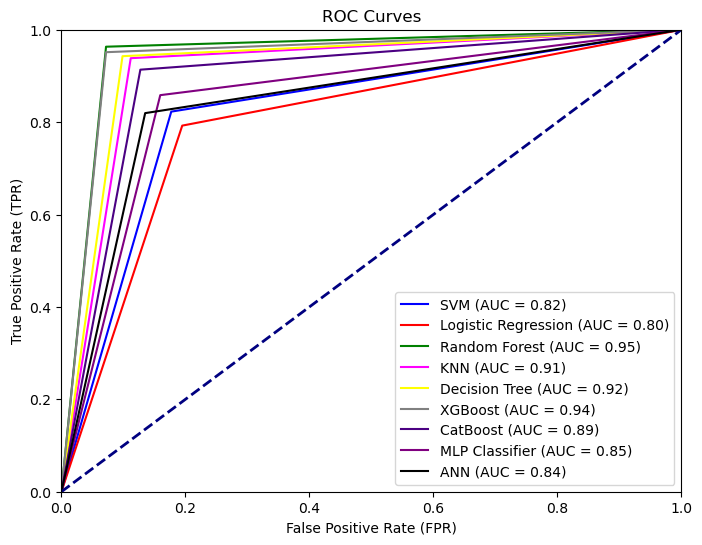

In [92]:
plt.figure(figsize=(8, 6))

plt.plot(fpr_1, tpr_1, label='SVM (AUC = %0.2f)' % auc_clf1, color='blue')
plt.plot(fpr_2, tpr_2, label='Logistic Regression (AUC = %0.2f)' % auc_clf2, color='red')
plt.plot(fpr_3, tpr_3, label='Random Forest (AUC = %0.2f)' % auc_clf3, color='green')
plt.plot(fpr_4, tpr_4, label='KNN (AUC = %0.2f)' % auc_clf4, color='magenta')
plt.plot(fpr_5, tpr_5, label='Decision Tree (AUC = %0.2f)' % auc_clf5, color='yellow')
plt.plot(fpr_6, tpr_6, label='XGBoost (AUC = %0.2f)' % auc_clf6, color='gray')
plt.plot(fpr_7, tpr_7, label='CatBoost (AUC = %0.2f)' % auc_clf7, color='indigo')
plt.plot(fpr_8, tpr_8, label='MLP Classifier (AUC = %0.2f)' % auc_clf8, color='purple')
plt.plot(fpr_9, tpr_9, label='ANN (AUC = %0.2f)' % auc_clf9, color='black')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.show()

# Hyper-parameter Tunning

In [116]:
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from scipy.stats import uniform, loguniform
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, make_scorer, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import log_loss

# SVM

In [94]:
param_grid = {'C': [0.1, 1, 10, 100, 1000], 
			'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
			'kernel': ['rbf','linear'],
            } 
model_svm=SVC()
grid_search_svm= GridSearchCV(estimator=model_svm, param_grid=param_grid,refit = True, cv=5, verbose = 3)
grid_search_svm.fit(x_new_train, y_new_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.912 total time=   3.5s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.924 total time=   2.8s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.916 total time=   3.2s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.927 total time=   3.1s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.915 total time=   2.7s
[CV 1/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.811 total time=   0.6s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.828 total time=   0.7s
[CV 3/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.799 total time=   0.7s
[CV 4/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.824 total time=   0.8s
[CV 5/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.801 total time=   0.7s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.824 total time=   1.7s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf', 'linear']},
             verbose=3)

In [95]:
print(grid_search_svm.best_params_) 
print(grid_search_svm.best_estimator_)

{'C': 10, 'gamma': 1, 'kernel': 'rbf'}
SVC(C=10, gamma=1)


In [97]:
y_pred_clf1 = grid_search_svm.predict(x_new_test) 
print(classification_report(y_new_test, y_pred_clf1, digits=4))

              precision    recall  f1-score   support

           0     0.9431    0.9734    0.9580       903
           1     0.9732    0.9427    0.9577       925

    accuracy                         0.9579      1828
   macro avg     0.9582    0.9581    0.9579      1828
weighted avg     0.9584    0.9579    0.9579      1828



In [98]:
def specificity_score(y_new_test, y_pred_clf1):
    cm = confusion_matrix(y_new_test, y_pred_clf1)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [99]:
accuracy = accuracy_score(y_new_test, y_pred_clf1)
precision = precision_score(y_new_test, y_pred_clf1)
recall = recall_score(y_new_test, y_pred_clf1)
f1 = f1_score(y_new_test, y_pred_clf1)
kappa = cohen_kappa_score(y_new_test, y_pred_clf1)
specificity = specificity_score(y_new_test, y_pred_clf1)

In [100]:
print(accuracy)
print(precision)
print(recall)
print(f1)
print(kappa)
print(specificity)

0.9578774617067833
0.9732142857142857
0.9427027027027027
0.9577155409115871
0.9157748858895588
0.973421926910299


In [101]:
auc = roc_auc_score(y_new_test, y_pred_clf1)
print("AUC: ", auc)

AUC:  0.958062314806501


In [102]:
fpr1, tpr1, _ = roc_curve(y_new_test, y_pred_clf1)
auc_clf1 = roc_auc_score(y_new_test, y_pred_clf1)

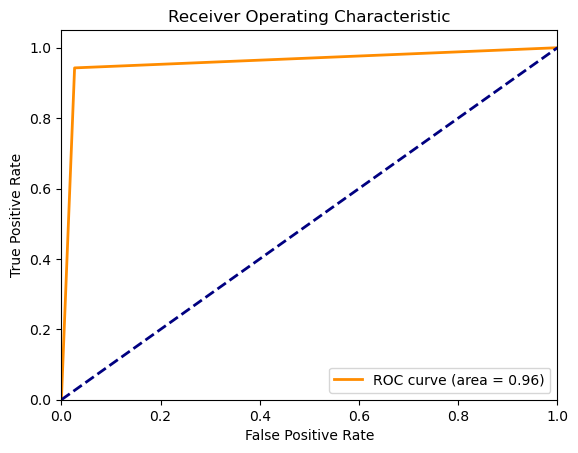

In [103]:
plt.figure()
plt.plot(fpr1, tpr1, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [104]:
loss = log_loss(y_new_test, y_pred_clf1 )
print(f'Log Loss: {loss}')

Log Loss: 1.5182501701105147


# Logistic Regression

In [129]:
model_lr = LogisticRegression(random_state= 42)
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'C': np.logspace(-4, 4, 20), 
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'l1_ratio': np.linspace(0, 1, 10) 
}
grid_search_lr = GridSearchCV(estimator= model_lr, param_grid= param_grid, cv=5, scoring= 'accuracy', n_jobs=-1, verbose=1)
grid_search_lr.fit(x_new_train, y_new_train)

Fitting 5 folds for each of 2400 candidates, totalling 12000 fits


GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                         'l1_ratio': array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ]),
                         'penalty': ['l1', 'l2', 'elasticnet', 'none'],
                         'solver': ['lbfgs', 'liblinear', 'saga']},
             scoring='accuracy', verbose=1)

In [130]:
print(grid_search_lr.best_params_) 
print(grid_search_lr.best_estimator_)

{'C': 0.08858667904100823, 'l1_ratio': 0.0, 'penalty': 'l1', 'solver': 'liblinear'}
LogisticRegression(C=0.08858667904100823, l1_ratio=0.0, penalty='l1',
                   random_state=42, solver='liblinear')


In [131]:
best_lr = grid_search_lr.best_estimator_
y_pred_clf2 = best_lr.predict(x_new_test)
print(classification_report(y_new_test, y_pred_clf2, digits=4))

              precision    recall  f1-score   support

           0     0.7928    0.8007    0.7967       903
           1     0.8035    0.7957    0.7996       925

    accuracy                         0.7981      1828
   macro avg     0.7981    0.7982    0.7981      1828
weighted avg     0.7982    0.7981    0.7981      1828



In [132]:
def specificity_score(y_new_test, y_pred_clf2 ):
    cm = confusion_matrix(y_new_test, y_pred_clf2)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [133]:
accuracy = accuracy_score(y_new_test, y_pred_clf2)
precision = precision_score(y_new_test, y_pred_clf2)
recall = recall_score(y_new_test, y_pred_clf2)
f1 = f1_score(y_new_test, y_pred_clf2)
kappa = cohen_kappa_score(y_new_test, y_pred_clf2)
specificity = specificity_score(y_new_test, y_pred_clf2)

In [134]:
print(accuracy)
print(precision)
print(recall)
print(f1)
print(kappa)
print(specificity)

0.7981400437636762
0.8034934497816594
0.7956756756756757
0.799565453557849
0.59626945535772
0.8006644518272426


In [135]:
auc = roc_auc_score(y_new_test, y_pred_clf2)
print("AUC: ", auc)

AUC:  0.798170063751459


In [136]:
fpr2, tpr2, _ = roc_curve(y_new_test, y_pred_clf2)
auc_clf2 = roc_auc_score(y_new_test, y_pred_clf2)

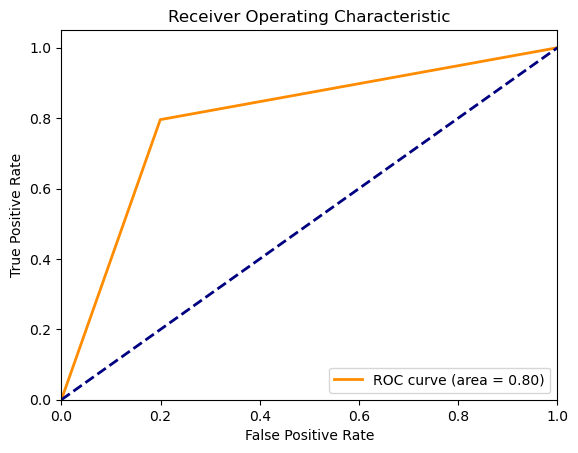

In [137]:
plt.figure()
plt.plot(fpr2, tpr2, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [138]:
loss = log_loss(y_new_test, y_pred_clf2 )
print(f'Log Loss: {loss}')

Log Loss: 7.275770295724414


# Random Forest

In [139]:
rf_model = RandomForestClassifier(random_state=42)
param_grid = { 
	'n_estimators': [25, 50, 100, 150], 
	'max_features': ['sqrt', 'log2'], 
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],  
    'criterion': ['gini', 'entropy']  
}
grid_search_rf = GridSearchCV(rf_model, param_grid, refit=True, cv=5, verbose=True, n_jobs=-1,scoring='accuracy')
grid_search_rf.fit(x_new_train, y_new_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'criterion': ['gini', 'entropy'],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [25, 50, 100, 150]},
             scoring='accuracy', verbose=True)

In [140]:
print(grid_search_rf.best_params_) 
print(grid_search_rf.best_estimator_)

{'bootstrap': False, 'criterion': 'gini', 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
RandomForestClassifier(bootstrap=False, random_state=42)


In [141]:
best_rf = grid_search_rf.best_estimator_
y_pred_clf3 = best_rf.predict(x_new_test)
print(classification_report(y_new_test, y_pred_clf3, digits=4))

              precision    recall  f1-score   support

           0     0.9593    0.9391    0.9491       903
           1     0.9417    0.9611    0.9513       925

    accuracy                         0.9502      1828
   macro avg     0.9505    0.9501    0.9502      1828
weighted avg     0.9504    0.9502    0.9502      1828



In [142]:
def specificity_score(y_new_test, y_pred_clf3 ):
    cm = confusion_matrix(y_new_test, y_pred_clf3)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [143]:
accuracy = accuracy_score(y_new_test, y_pred_clf3)
precision = precision_score(y_new_test, y_pred_clf3)
recall = recall_score(y_new_test, y_pred_clf3)
f1 = f1_score(y_new_test, y_pred_clf3)
kappa = cohen_kappa_score(y_new_test, y_pred_clf3)
specificity = specificity_score(y_new_test, y_pred_clf3)

In [144]:
print(accuracy)
print(precision)
print(recall)
print(f1)
print(kappa)
print(specificity)

0.950218818380744
0.9417372881355932
0.961081081081081
0.951310861423221
0.9003982918715407
0.9390919158361019


In [145]:
auc = roc_auc_score(y_new_test, y_pred_clf3)
print("AUC: ", auc)

AUC:  0.9500864984585915


In [146]:
fpr3, tpr3, _ = roc_curve(y_new_test, y_pred_clf3)
auc_clf3 = roc_auc_score(y_new_test, y_pred_clf3)

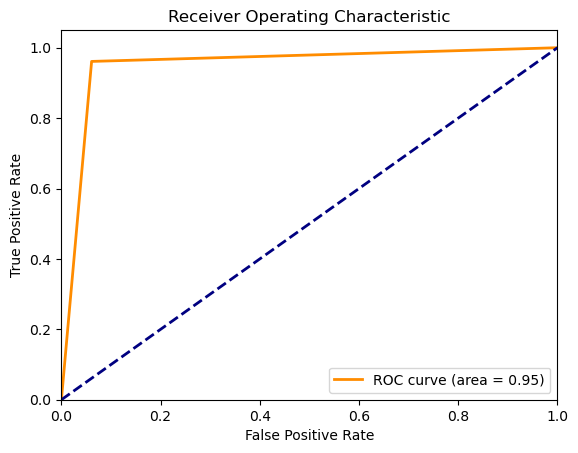

In [147]:
plt.figure()
plt.plot(fpr3, tpr3, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [148]:
loss = log_loss(y_new_test, y_pred_clf3 )
print(f'Log Loss: {loss}')

Log Loss: 1.794295655585154


# KNN

In [149]:
param_grid = {
    "n_neighbors" : [3,4,5,8,10],
    'metric': ['euclidean', 'manhattan'],
    "weights" : ["uniform","distance"],
    "algorithm" : ["auto","ball_tree","kd_tree","brute"],
    "leaf_size" : [10,20,30,40,50],
}

model_knn = KNeighborsClassifier()
grid_search_knn= GridSearchCV( model_knn, param_grid, n_jobs=-1, verbose=2)
grid_search_knn.fit(x_new_train, y_new_train)

Fitting 5 folds for each of 400 candidates, totalling 2000 fits


GridSearchCV(estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'leaf_size': [10, 20, 30, 40, 50],
                         'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 4, 5, 8, 10],
                         'weights': ['uniform', 'distance']},
             verbose=2)

In [150]:
print(grid_search_knn.best_params_) 
print(grid_search_knn.best_estimator_)

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
KNeighborsClassifier(metric='manhattan', n_neighbors=4, weights='distance')


In [151]:
best_knn = grid_search_knn.best_estimator_
y_pred_clf4 = best_knn.predict(x_new_test)
print(classification_report(y_new_test, y_pred_clf4, digits=4))

              precision    recall  f1-score   support

           0     0.9646    0.9358    0.9500       903
           1     0.9391    0.9665    0.9526       925

    accuracy                         0.9513      1828
   macro avg     0.9518    0.9511    0.9513      1828
weighted avg     0.9517    0.9513    0.9513      1828



In [152]:
def specificity_score(y_new_test, y_pred_clf4 ):
    cm = confusion_matrix(y_new_test, y_pred_clf4)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [153]:
accuracy = accuracy_score(y_new_test, y_pred_clf4)
precision = precision_score(y_new_test, y_pred_clf4)
recall = recall_score(y_new_test, y_pred_clf4)
f1 = f1_score(y_new_test, y_pred_clf4)
kappa = cohen_kappa_score(y_new_test, y_pred_clf4)
specificity = specificity_score(y_new_test, y_pred_clf4)

In [154]:
print(accuracy)
print(precision)
print(recall)
print(f1)
print(kappa)
print(specificity)

0.9513129102844639
0.9390756302521008
0.9664864864864865
0.9525839104954715
0.9025770738869767
0.9357696566998892


In [155]:
auc = roc_auc_score(y_new_test, y_pred_clf4)
print("AUC: ", auc)

AUC:  0.9511280715931877


In [156]:
fpr4, tpr4, _ = roc_curve(y_new_test, y_pred_clf4)
auc_clf4 = roc_auc_score(y_new_test, y_pred_clf4)

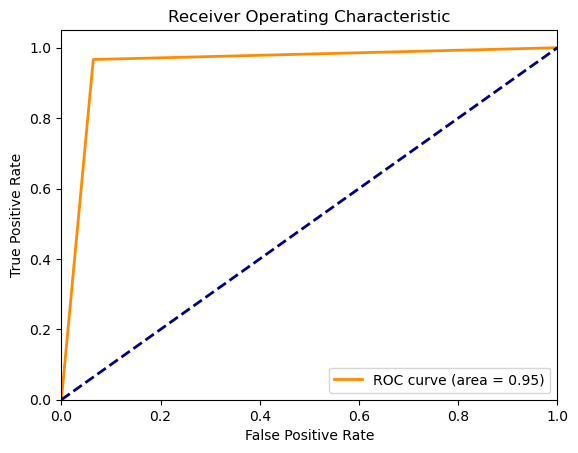

In [157]:
plt.figure()
plt.plot(fpr4, tpr4, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [158]:
loss = log_loss(y_new_test, y_pred_clf4 )
print(f'Log Loss: {loss}')

Log Loss: 1.7548605862316335


# Decision Tree

In [159]:
model_dt = tree.DecisionTreeClassifier()
param_grid= {
    "criterion" : ["gini","entropy","log_loss"],
    "splitter" : ["best","random"], 
    "min_samples_split" : [1,2,3,4,5], 
    "max_features" : ["auto","sqrt","log2"] 
}
grid_search_dt = GridSearchCV( model_dt, param_grid, cv = 5, n_jobs=-1, verbose=2)
grid_search_dt.fit(x_new_train, y_new_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_split': [1, 2, 3, 4, 5],
                         'splitter': ['best', 'random']},
             verbose=2)

In [160]:
print(grid_search_dt.best_params_) 
print(grid_search_dt.best_estimator_)

{'criterion': 'gini', 'max_features': 'sqrt', 'min_samples_split': 2, 'splitter': 'best'}
DecisionTreeClassifier(max_features='sqrt')


In [161]:
best_dt = grid_search_dt.best_estimator_
y_pred_clf5 = best_dt.predict(x_new_test)
print(classification_report(y_new_test, y_pred_clf5, digits=4))

              precision    recall  f1-score   support

           0     0.9340    0.8926    0.9128       903
           1     0.8995    0.9384    0.9185       925

    accuracy                         0.9158      1828
   macro avg     0.9167    0.9155    0.9157      1828
weighted avg     0.9165    0.9158    0.9157      1828



In [162]:
def specificity_score(y_new_test, y_pred_clf5 ):
    cm = confusion_matrix(y_new_test, y_pred_clf5)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [163]:
accuracy = accuracy_score(y_new_test, y_pred_clf5)
precision = precision_score(y_new_test,y_pred_clf5)
recall = recall_score(y_new_test, y_pred_clf5)
f1 = f1_score(y_new_test, y_pred_clf5)
kappa = cohen_kappa_score(y_new_test, y_pred_clf5)
specificity = specificity_score(y_new_test, y_pred_clf5)

In [164]:
print(accuracy)
print(precision)
print(recall)
print(f1)
print(kappa)
print(specificity)

0.9157549234135668
0.8994818652849741
0.9383783783783783
0.9185185185185185
0.8313966232848408
0.8925802879291251


In [165]:
auc = roc_auc_score(y_new_test, y_pred_clf5)
print("AUC: ", auc)

AUC:  0.9154793331537517


In [166]:
fpr5, tpr5, _ = roc_curve(y_new_test, y_pred_clf5)
auc_clf5 = roc_auc_score(y_new_test, y_pred_clf5)

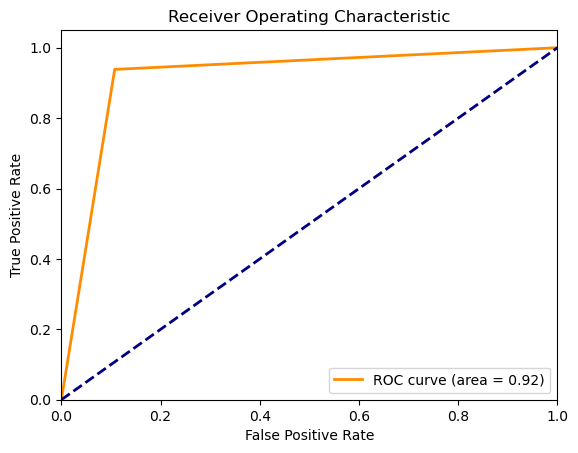

In [167]:
plt.figure()
plt.plot(fpr5, tpr5, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [168]:
loss = log_loss(y_new_test, y_pred_clf5 )
print(f'Log Loss: {loss}')

Log Loss: 3.036500340221029


# XGBoost

In [169]:
xgb = XGBClassifier(enable_categorical=True, random_state=42)
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [1, 2, 3],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2]
}
grid_search_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search_xgb.fit(x_new_train, y_new_train)

Fitting 5 folds for each of 5184 candidates, totalling 25920 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, m...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
                         'gamma': [0, 0.1, 0.2],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 4, 5, 6],
                         'min_child_weight': [1, 2, 3],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.6, 0.7, 0.8, 0.9]},
             verbose=2)

In [170]:
print(grid_search_xgb.best_params_) 
print(grid_search_xgb.best_estimator_)

{'colsample_bytree': 0.9, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.7}
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)


In [171]:
best_xgb = grid_search_xgb.best_estimator_
y_pred_clf6 = best_xgb.predict(x_new_test)
print(classification_report(y_new_test, y_pred_clf6, digits=4))

              precision    recall  f1-score   support

           0     0.9536    0.9324    0.9429       903
           1     0.9354    0.9557    0.9455       925

    accuracy                         0.9442      1828
   macro avg     0.9445    0.9441    0.9442      1828
weighted avg     0.9444    0.9442    0.9442      1828



In [172]:
def specificity_score(y_new_test, y_pred_clf6 ):
    cm = confusion_matrix(y_new_test, y_pred_clf6)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [173]:
accuracy = accuracy_score(y_new_test, y_pred_clf6)
precision = precision_score(y_new_test, y_pred_clf6)
recall = recall_score(y_new_test, y_pred_clf6)
f1 = f1_score(y_new_test, y_pred_clf6)
kappa = cohen_kappa_score(y_new_test, y_pred_clf6)
specificity = specificity_score(y_new_test, y_pred_clf6)

In [174]:
print(accuracy)
print(precision)
print(recall)
print(f1)
print(kappa)
print(specificity)

0.9442013129102844
0.9354497354497354
0.9556756756756757
0.9454545454545454
0.888357054325763
0.9324473975636767


In [175]:
auc = roc_auc_score(y_new_test, y_pred_clf6)
print("AUC: ", auc)

AUC:  0.9440615366196762


In [176]:
fpr6, tpr6, _ = roc_curve(y_new_test, y_pred_clf6)
auc_clf6 = roc_auc_score(y_new_test, y_pred_clf6)

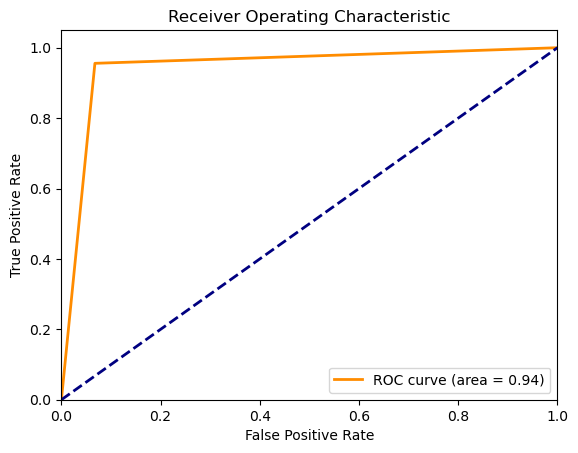

In [177]:
plt.figure()
plt.plot(fpr6, tpr6, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [178]:
loss = log_loss(y_new_test, y_pred_clf6 )
print(f'Log Loss: {loss}')

Log Loss: 2.011188537029513


# CatBoost

In [179]:
cat_features =['V013', 'V024', 'V025', 'V106', 'V701', 'V201', 'V122', 'V159', 'V704','V190', 'V161', 'V404']
model_cb = CatBoostClassifier(random_seed=42, verbose=False,cat_features = cat_features )
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 200, 300],
    'l2_leaf_reg': [1, 3, 5, 7, 9]
}
grid_search_cb = GridSearchCV(estimator= model_cb, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search_cb.fit(x_new_train, y_new_train)

Fitting 5 folds for each of 135 candidates, totalling 675 fits


GridSearchCV(cv=5,
             estimator=<catboost.core.CatBoostClassifier object at 0x0000023466104B90>,
             n_jobs=-1,
             param_grid={'depth': [4, 6, 8], 'iterations': [100, 200, 300],
                         'l2_leaf_reg': [1, 3, 5, 7, 9],
                         'learning_rate': [0.01, 0.05, 0.1]},
             verbose=2)

In [180]:
print(grid_search_cb.best_params_) 
print(grid_search_cb.best_estimator_)

{'depth': 8, 'iterations': 300, 'l2_leaf_reg': 3, 'learning_rate': 0.1}


In [181]:
best_cb = grid_search_cb.best_estimator_
y_pred_clf7 = best_cb.predict(x_new_test)
print(classification_report(y_new_test, y_pred_clf7, digits=4))

              precision    recall  f1-score   support

           0     0.9319    0.8948    0.9130       903
           1     0.9011    0.9362    0.9183       925

    accuracy                         0.9158      1828
   macro avg     0.9165    0.9155    0.9157      1828
weighted avg     0.9164    0.9158    0.9157      1828



In [182]:
def specificity_score(y_new_test, y_pred_clf7 ):
    cm = confusion_matrix(y_new_test, y_pred_clf7)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [183]:
accuracy = accuracy_score(y_new_test, y_pred_clf7)
precision = precision_score(y_new_test, y_pred_clf7)
recall = recall_score(y_new_test,y_pred_clf7)
f1 = f1_score(y_new_test, y_pred_clf7)
kappa = cohen_kappa_score(y_new_test, y_pred_clf7)
specificity = specificity_score(y_new_test, y_pred_clf7)

In [184]:
print(accuracy)
print(precision)
print(recall)
print(f1)
print(kappa)
print(specificity)

0.9157549234135668
0.9011446409989594
0.9362162162162162
0.9183457051961824
0.8314055090617922
0.8947951273532669


In [185]:
auc = roc_auc_score(y_new_test, y_pred_clf7)
print("AUC: ", auc)

AUC:  0.9155056717847415


In [186]:
fpr7, tpr7, _ = roc_curve(y_new_test, y_pred_clf7)
auc_clf7 = roc_auc_score(y_new_test, y_pred_clf7)

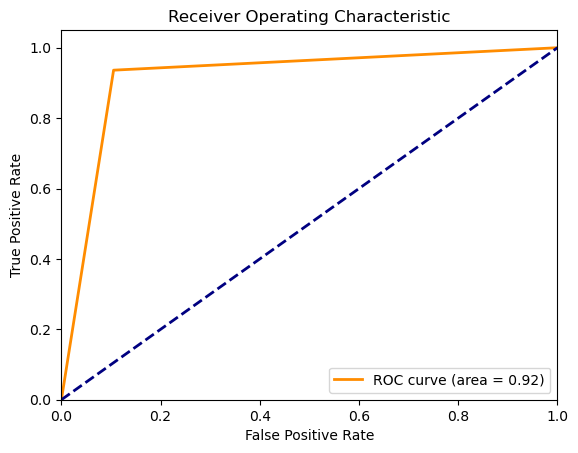

In [187]:
plt.figure()
plt.plot(fpr7, tpr7, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [188]:
loss = log_loss(y_new_test, y_pred_clf7 )
print(f'Log Loss: {loss}')

Log Loss: 3.0365003402210293


# MLP Classifier

In [189]:
model_mlp=MLPClassifier(random_state=42)
param_grid= {
   'hidden_layer_sizes': [(50,), (50,50), (100,),(100,50)],
    'activation': ['tanh', 'relu','logistic'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001,0.001,.01, 0.05],
    'learning_rate': ['constant','adaptive','invscaling'],
}
grid_search_mlp= GridSearchCV( model_mlp, param_grid, cv = 5, n_jobs=-1, verbose=2)
grid_search_mlp.fit(x_new_train, y_new_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


GridSearchCV(cv=5, estimator=MLPClassifier(random_state=42), n_jobs=-1,
             param_grid={'activation': ['tanh', 'relu', 'logistic'],
                         'alpha': [0.0001, 0.001, 0.01, 0.05],
                         'hidden_layer_sizes': [(50,), (50, 50), (100,),
                                                (100, 50)],
                         'learning_rate': ['constant', 'adaptive',
                                           'invscaling'],
                         'solver': ['sgd', 'adam']},
             verbose=2)

In [190]:
print(grid_search_mlp.best_params_) 
print(grid_search_mlp.best_estimator_)

{'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant', 'solver': 'adam'}
MLPClassifier(hidden_layer_sizes=(100, 50), random_state=42)


In [191]:
best_mlp = grid_search_mlp.best_estimator_
y_pred_clf8 = best_cb.predict(x_new_test)
print(classification_report(y_new_test, y_pred_clf8, digits=4))

              precision    recall  f1-score   support

           0     0.9319    0.8948    0.9130       903
           1     0.9011    0.9362    0.9183       925

    accuracy                         0.9158      1828
   macro avg     0.9165    0.9155    0.9157      1828
weighted avg     0.9164    0.9158    0.9157      1828



In [192]:
def specificity_score(y_new_test, y_pred_clf8 ):
    cm = confusion_matrix(y_new_test, y_pred_clf8)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [193]:
accuracy = accuracy_score(y_new_test, y_pred_clf8)
precision = precision_score(y_new_test,y_pred_clf8)
recall = recall_score(y_new_test, y_pred_clf8)
f1 = f1_score(y_new_test, y_pred_clf8)
kappa = cohen_kappa_score(y_new_test, y_pred_clf8)
specificity = specificity_score(y_new_test, y_pred_clf8)

In [194]:
print(accuracy)
print(precision)
print(recall)
print(f1)
print(kappa)
print(specificity)

0.9157549234135668
0.9011446409989594
0.9362162162162162
0.9183457051961824
0.8314055090617922
0.8947951273532669


In [195]:
auc = roc_auc_score(y_new_test, y_pred_clf8)
print("AUC: ", auc)

AUC:  0.9155056717847415


In [196]:
fpr8, tpr8, _ = roc_curve(y_new_test, y_pred_clf8)
auc_clf8 = roc_auc_score(y_new_test, y_pred_clf8)

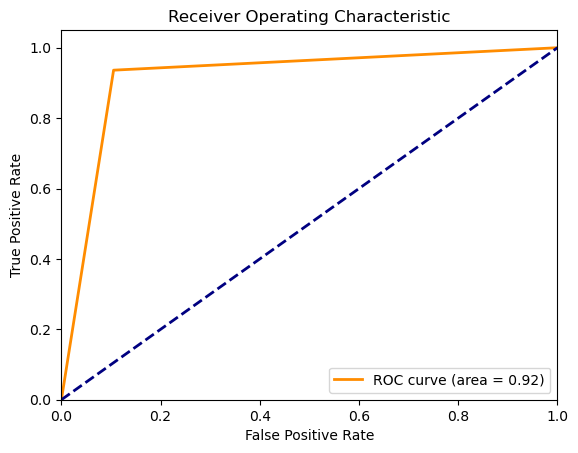

In [197]:
plt.figure()
plt.plot(fpr8, tpr8, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [198]:
loss = log_loss(y_new_test, y_pred_clf8 )
print(f'Log Loss: {loss}')

Log Loss: 3.0365003402210293


# ANN

In [199]:
model_ann = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(20,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

In [201]:
model_ann.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model_ann.fit(x_new_train, y_new_train, epochs=2000, batch_size=32, validation_data=(x_new_test, y_new_test))

ValueError: Invalid dtype: category

In [ ]:
y_pred_clf9 = (model_ann.predict(x_new_test) > 0.5).astype("int32")
print(classification_report(y_new_test, y_pred_clf9, digits=4))

In [ ]:
print(model_ann.best_params_) 
print(model_ann.best_estimator_)

In [ ]:
accuracy = accuracy_score(y_new_test, y_pred_clf9)
precision = precision_score(y_new_test, y_pred_clf9)
recall = recall_score(y_new_test, y_pred_clf9)
f1 = f1_score(y_new_test, y_pred_clf9)
kappa = cohen_kappa_score(y_new_test, y_pred_clf9)
specificity = specificity_score(y_new_test, y_pred_clf9)

In [ ]:
print(accuracy)
print(precision)
print(recall)
print(f1)
print(kappa)
print(specificity)

In [ ]:
auc = roc_auc_score(y_new_test, y_pred_clf9)
print("AUC: ", auc)

In [ ]:
fpr9, tpr9, _ = roc_curve(y_new_test, y_pred_clf9)
auc_clf9 = roc_auc_score(y_new_test, y_pred_clf9)

In [ ]:
plt.figure()
plt.plot(fpr9, tpr9, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [ ]:
loss = log_loss(y_new_test, y_pred_clf9 )
print(f'Log Loss: {loss}')

# Combined ROC Curve

In [202]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [204]:
fpr_1, tpr_1, thresholds = roc_curve(y_new_test, y_pred_clf1)
auc_clf1 = auc(fpr1, tpr1)

fpr_2, tpr_2, thresholds = roc_curve(y_new_test, y_pred_clf2)
auc_clf2 = auc(fpr2, tpr2)

fpr_3, tpr_3, thresholds = roc_curve(y_new_test, y_pred_clf3)
auc_clf3 = auc(fpr3, tpr3)

fpr_4, tpr_4, thresholds = roc_curve(y_new_test, y_pred_clf4)
auc_clf4 = auc(fpr4, tpr4)

fpr_5, tpr_5, thresholds = roc_curve(y_new_test, y_pred_clf5)
auc_clf5 = auc(fpr5, tpr5)

fpr_6, tpr_6, thresholds = roc_curve(y_new_test, y_pred_clf6)
auc_clf6 = auc(fpr6, tpr6)

fpr_7, tpr_7, thresholds = roc_curve(y_new_test, y_pred_clf7)
auc_clf7 = auc(fpr7, tpr7)

fpr_8, tpr_8, thresholds = roc_curve(y_new_test, y_pred_clf8)
auc_clf8 = auc(fpr8, tpr8)


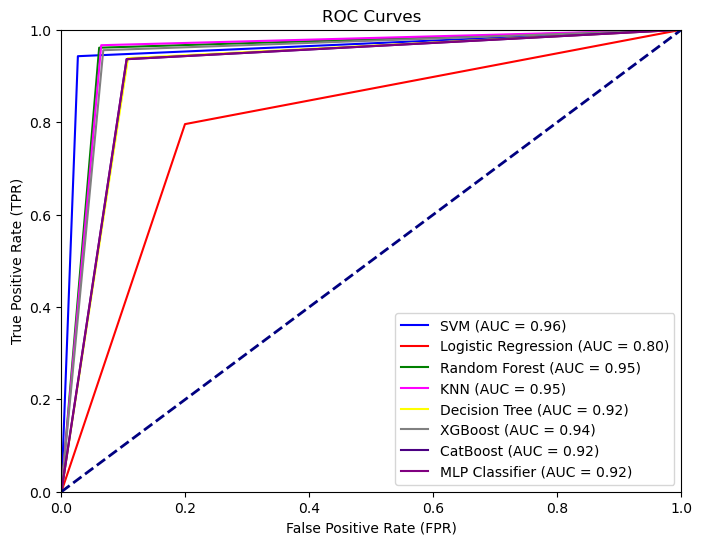

In [205]:
plt.figure(figsize=(8, 6))

plt.plot(fpr_1, tpr_1, label='SVM (AUC = %0.2f)' % auc_clf1, color='blue')
plt.plot(fpr_2, tpr_2, label='Logistic Regression (AUC = %0.2f)' % auc_clf2, color='red')
plt.plot(fpr_3, tpr_3, label='Random Forest (AUC = %0.2f)' % auc_clf3, color='green')
plt.plot(fpr_4, tpr_4, label='KNN (AUC = %0.2f)' % auc_clf4, color='magenta')
plt.plot(fpr_5, tpr_5, label='Decision Tree (AUC = %0.2f)' % auc_clf5, color='yellow')
plt.plot(fpr_6, tpr_6, label='XGBoost (AUC = %0.2f)' % auc_clf6, color='gray')
plt.plot(fpr_7, tpr_7, label='CatBoost (AUC = %0.2f)' % auc_clf7, color='indigo')
plt.plot(fpr_8, tpr_8, label='MLP Classifier (AUC = %0.2f)' % auc_clf8, color='purple')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.show()